# Problem 1: Implementation from Scratch - AdaGrad

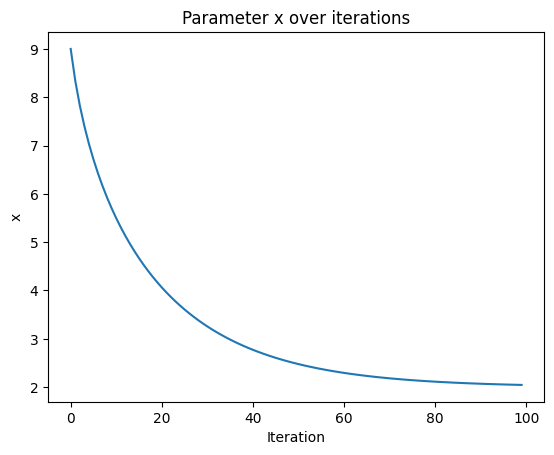

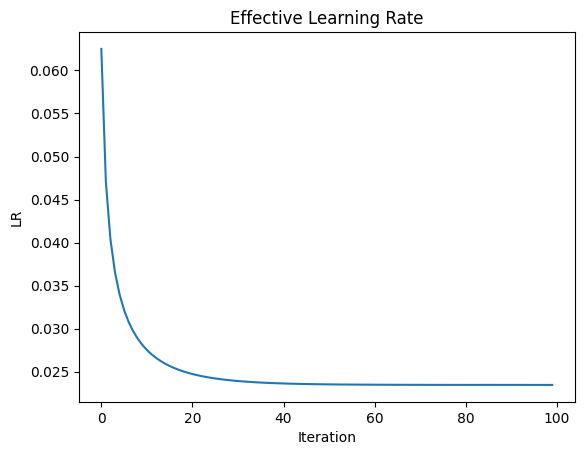

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class AdaGradOptimizerScratch:
    def __init__(self, lr=1.0, epsilon=1e-8):
        self.lr = lr
        self.epsilon = epsilon
        self.G = 0  # accumulated squared gradients

    def update(self, x, grad):
        self.G += grad**2
        adjusted_lr = self.lr / (np.sqrt(self.G) + self.epsilon)
        x = x - adjusted_lr * grad
        return x, adjusted_lr

# Function: f(x) = x^2 - 4x + 4
def grad(x):
    return 2*x - 4

x = 10
optimizer = AdaGradOptimizerScratch(lr=1.0)

x_history = []
lr_history = []

for i in range(100):
    g = grad(x)
    x, eff_lr = optimizer.update(x, g)
    x_history.append(x)
    lr_history.append(eff_lr)

# Plot parameter
plt.plot(x_history)
plt.title("Parameter x over iterations")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

# Plot effective learning rate
plt.plot(lr_history)
plt.title("Effective Learning Rate")
plt.xlabel("Iteration")
plt.ylabel("LR")
plt.show()

From the plots, it can be observed that the parameter
𝑥
x decreases rapidly from the initial value (x=10) and approaches the optimal value (x=2) within the first iterations. However, as the iterations continue, the updates become progressively smaller and the parameter converges more slowly to the minimum.

This behavior is directly related to the effective learning rate. The effective learning rate starts relatively high but decreases monotonically over time because AdaGrad accumulates the squared gradients in the denominator. As a result, the step size shrinks at every iteration.

This explains why AdaGrad achieves fast initial convergence but suffers from very slow updates in later stages. While it is effective for quickly moving toward the minimum, it may become too conservative and slow down significantly near convergence.

# Problem 2: Application & Benchmarking on Fashion-MNIST

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# Dataset
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32*7*7,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.model(x)

In [5]:
def train_and_evaluate(optimizer_name):
    model = CNN().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(20):
        # TRAIN
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        # VALIDATION
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"{optimizer_name} | Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")

    return train_losses, val_losses, val_accuracies

In [6]:
sgd_train, sgd_val, sgd_acc = train_and_evaluate("SGD")
adam_train, adam_val, adam_acc = train_and_evaluate("Adam")
adamw_train, adamw_val, adamw_acc = train_and_evaluate("AdamW")

SGD | Epoch 1: Train Loss=0.6798, Val Loss=0.4368, Acc=0.8462
SGD | Epoch 2: Train Loss=0.3894, Val Loss=0.3627, Acc=0.8667
SGD | Epoch 3: Train Loss=0.3235, Val Loss=0.3531, Acc=0.8720
SGD | Epoch 4: Train Loss=0.2892, Val Loss=0.3181, Acc=0.8839
SGD | Epoch 5: Train Loss=0.2681, Val Loss=0.2981, Acc=0.8932
SGD | Epoch 6: Train Loss=0.2482, Val Loss=0.2835, Acc=0.8963
SGD | Epoch 7: Train Loss=0.2327, Val Loss=0.2815, Acc=0.8994
SGD | Epoch 8: Train Loss=0.2204, Val Loss=0.2685, Acc=0.9022
SGD | Epoch 9: Train Loss=0.2051, Val Loss=0.2744, Acc=0.8999
SGD | Epoch 10: Train Loss=0.1955, Val Loss=0.2505, Acc=0.9102
SGD | Epoch 11: Train Loss=0.1826, Val Loss=0.2751, Acc=0.9043
SGD | Epoch 12: Train Loss=0.1753, Val Loss=0.2538, Acc=0.9079
SGD | Epoch 13: Train Loss=0.1670, Val Loss=0.2466, Acc=0.9166
SGD | Epoch 14: Train Loss=0.1563, Val Loss=0.2569, Acc=0.9134
SGD | Epoch 15: Train Loss=0.1478, Val Loss=0.2438, Acc=0.9167
SGD | Epoch 16: Train Loss=0.1376, Val Loss=0.2521, Acc=0.9134
S

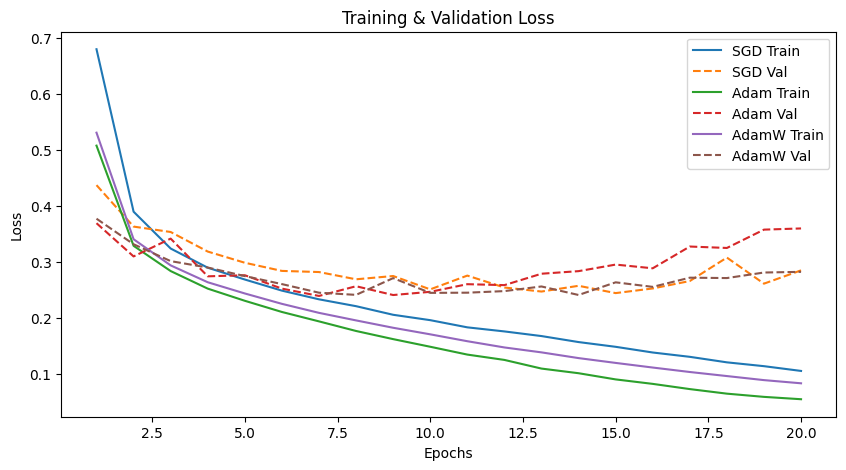

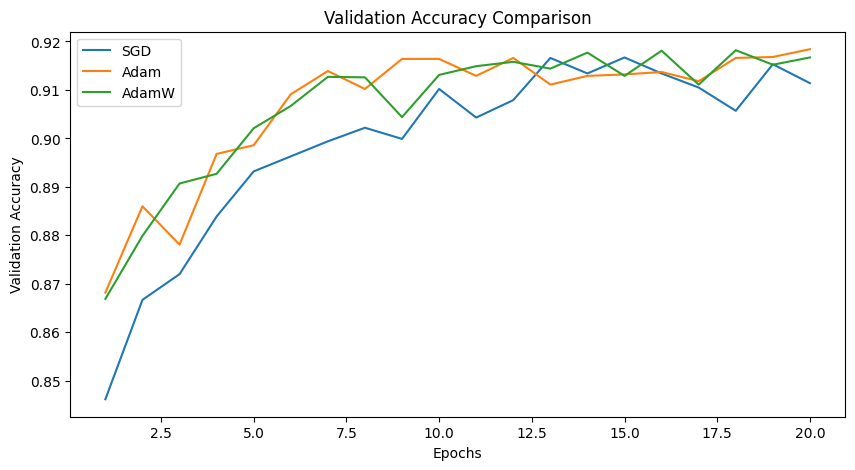

In [7]:
import matplotlib.pyplot as plt

epochs = range(1, 21)

# 📊 LOSS PLOT
plt.figure(figsize=(10,5))

plt.plot(epochs, sgd_train, label="SGD Train")
plt.plot(epochs, sgd_val, '--', label="SGD Val")

plt.plot(epochs, adam_train, label="Adam Train")
plt.plot(epochs, adam_val, '--', label="Adam Val")

plt.plot(epochs, adamw_train, label="AdamW Train")
plt.plot(epochs, adamw_val, '--', label="AdamW Val")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()


# 📈 ACCURACY PLOT
plt.figure(figsize=(10,5))

plt.plot(epochs, sgd_acc, label="SGD")
plt.plot(epochs, adam_acc, label="Adam")
plt.plot(epochs, adamw_acc, label="AdamW")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

The experimental results reveal clear differences among the three optimizers in terms of convergence speed, final performance, and generalization ability.

In terms of convergence speed, Adam and AdamW converge significantly faster than SGD with momentum. From the early epochs, both adaptive optimizers achieve lower training and validation loss values, while SGD requires more epochs to reach a similar performance level. This behavior is expected since Adam-based methods adjust the learning rate dynamically for each parameter, enabling faster optimization.

Regarding final performance, AdamW achieves the highest validation accuracy, reaching approximately 91.6–91.8%, while SGD remains slightly lower. Adam also performs competitively but does not surpass AdamW. This indicates that the decoupled weight decay mechanism in AdamW provides a clear advantage in terms of final model performance.

When analyzing generalization, the gap between training and validation loss is slightly smaller for AdamW compared to Adam. While Adam achieves low training loss, its validation loss fluctuates more, suggesting mild overfitting. In contrast, AdamW maintains a more stable validation curve, indicating better generalization. SGD shows relatively stable behavior but underperforms in overall accuracy.

Based on these observations, AdamW is the most suitable optimizer for this task, as it provides a strong balance between fast convergence and good generalization. Its ability to control overfitting through weight decay makes it particularly effective for image classification problems like Fashion-MNIST.

# Problem 3: Hyperparameter Sensitivity Analysis

In [8]:
def train_with_betas(beta1, beta2):
    model = CNN().to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        betas=(beta1, beta2),
        weight_decay=0.01
    )

    val_accuracies = []

    for epoch in range(15):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

        # VALIDATION
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        acc = correct / total
        val_accuracies.append(acc)

        print(f"beta1={beta1}, beta2={beta2} | Epoch {epoch+1} Acc={acc:.4f}")

    return val_accuracies

# EXPERIMENT A — beta1

In [9]:
acc_b1_08 = train_with_betas(0.8, 0.999)
acc_b1_09 = train_with_betas(0.9, 0.999)
acc_b1_095 = train_with_betas(0.95, 0.999)

beta1=0.8, beta2=0.999 | Epoch 1 Acc=0.8611
beta1=0.8, beta2=0.999 | Epoch 2 Acc=0.8694
beta1=0.8, beta2=0.999 | Epoch 3 Acc=0.8798
beta1=0.8, beta2=0.999 | Epoch 4 Acc=0.8904
beta1=0.8, beta2=0.999 | Epoch 5 Acc=0.9040
beta1=0.8, beta2=0.999 | Epoch 6 Acc=0.9014
beta1=0.8, beta2=0.999 | Epoch 7 Acc=0.9088
beta1=0.8, beta2=0.999 | Epoch 8 Acc=0.9050
beta1=0.8, beta2=0.999 | Epoch 9 Acc=0.9144
beta1=0.8, beta2=0.999 | Epoch 10 Acc=0.9182
beta1=0.8, beta2=0.999 | Epoch 11 Acc=0.9165
beta1=0.8, beta2=0.999 | Epoch 12 Acc=0.9191
beta1=0.8, beta2=0.999 | Epoch 13 Acc=0.9168
beta1=0.8, beta2=0.999 | Epoch 14 Acc=0.9157
beta1=0.8, beta2=0.999 | Epoch 15 Acc=0.9123
beta1=0.9, beta2=0.999 | Epoch 1 Acc=0.8547
beta1=0.9, beta2=0.999 | Epoch 2 Acc=0.8754
beta1=0.9, beta2=0.999 | Epoch 3 Acc=0.8825
beta1=0.9, beta2=0.999 | Epoch 4 Acc=0.8973
beta1=0.9, beta2=0.999 | Epoch 5 Acc=0.8977
beta1=0.9, beta2=0.999 | Epoch 6 Acc=0.9004
beta1=0.9, beta2=0.999 | Epoch 7 Acc=0.9044
beta1=0.9, beta2=0.999 | E

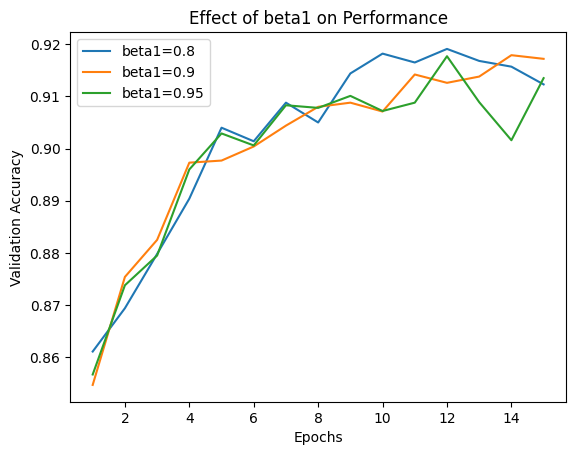

In [10]:
# plot A
import matplotlib.pyplot as plt

epochs = range(1,16)

plt.plot(epochs, acc_b1_08, label="beta1=0.8")
plt.plot(epochs, acc_b1_09, label="beta1=0.9")
plt.plot(epochs, acc_b1_095, label="beta1=0.95")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Effect of beta1 on Performance")
plt.legend()
plt.show()

# EXPERIMENT B — beta2

In [11]:
acc_b2_09 = train_with_betas(0.9, 0.9)
acc_b2_099 = train_with_betas(0.9, 0.99)
acc_b2_09999 = train_with_betas(0.9, 0.9999)

beta1=0.9, beta2=0.9 | Epoch 1 Acc=0.8551
beta1=0.9, beta2=0.9 | Epoch 2 Acc=0.8851
beta1=0.9, beta2=0.9 | Epoch 3 Acc=0.8926
beta1=0.9, beta2=0.9 | Epoch 4 Acc=0.8906
beta1=0.9, beta2=0.9 | Epoch 5 Acc=0.9046
beta1=0.9, beta2=0.9 | Epoch 6 Acc=0.9002
beta1=0.9, beta2=0.9 | Epoch 7 Acc=0.9135
beta1=0.9, beta2=0.9 | Epoch 8 Acc=0.9151
beta1=0.9, beta2=0.9 | Epoch 9 Acc=0.9125
beta1=0.9, beta2=0.9 | Epoch 10 Acc=0.9137
beta1=0.9, beta2=0.9 | Epoch 11 Acc=0.9164
beta1=0.9, beta2=0.9 | Epoch 12 Acc=0.9155
beta1=0.9, beta2=0.9 | Epoch 13 Acc=0.9179
beta1=0.9, beta2=0.9 | Epoch 14 Acc=0.9143
beta1=0.9, beta2=0.9 | Epoch 15 Acc=0.9143
beta1=0.9, beta2=0.99 | Epoch 1 Acc=0.8474
beta1=0.9, beta2=0.99 | Epoch 2 Acc=0.8696
beta1=0.9, beta2=0.99 | Epoch 3 Acc=0.8972
beta1=0.9, beta2=0.99 | Epoch 4 Acc=0.9064
beta1=0.9, beta2=0.99 | Epoch 5 Acc=0.9059
beta1=0.9, beta2=0.99 | Epoch 6 Acc=0.9068
beta1=0.9, beta2=0.99 | Epoch 7 Acc=0.9084
beta1=0.9, beta2=0.99 | Epoch 8 Acc=0.9111
beta1=0.9, beta2=0.9

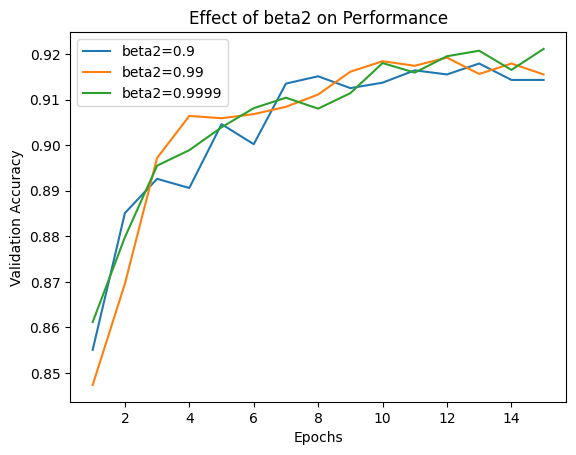

In [12]:
# plot B
plt.plot(epochs, acc_b2_09, label="beta2=0.9")
plt.plot(epochs, acc_b2_099, label="beta2=0.99")
plt.plot(epochs, acc_b2_09999, label="beta2=0.9999")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Effect of beta2 on Performance")
plt.legend()
plt.show()

The hyperparameter sensitivity analysis highlights the significant impact of AdamW’s beta parameters on both convergence behavior and final performance.

In Experiment A (varying beta1), it is observed that higher values of beta1 (e.g., 0.95) lead to more stable and consistent validation accuracy across epochs. Lower beta1 values such as 0.8 result in faster but more fluctuating learning behavior due to reduced reliance on past gradients. This confirms that beta1 controls the momentum effect, where higher values increase the optimizer’s “memory” of previous gradients, leading to smoother but slightly less responsive updates. Among the tested values, beta1 = 0.95 achieved the most stable and highest validation accuracy (~0.91+), indicating better convergence behavior.

In Experiment B (varying beta2), the results show that moderate values such as 0.999 provide the best balance between adaptability and stability. Lower beta2 values (e.g., 0.9) allow the adaptive learning rate to change rapidly, which can introduce instability. On the other hand, very high values like 0.9999 make the optimizer overly conservative, slowing down adaptation to gradient changes. This confirms that beta2 controls how quickly the second moment estimate adapts, directly affecting the responsiveness of the learning rate.

Overall, the results demonstrate that beta1 primarily affects stability through gradient memory, while beta2 controls the adaptability of the learning rate. The combination of beta1=0.95 and beta2=0.999 produced the best performance in this experiment, achieving both stable convergence and high validation accuracy.

# Problem 4: Research and Critical Thinking

Citation

Liu, L., Jiang, H., He, P., Chen, W., Liu, X., Gao, J., & Han, J. (2020).
On the Variance of the Adaptive Learning Rate and Beyond.
International Conference on Learning Representations (ICLR 2020).

PDF Link:
https://arxiv.org/pdf/1908.03265.pdf

RAdam (Rectified Adam) is designed to address a fundamental limitation of Adam related to the high variance of adaptive learning rates during the early stages of training. In standard Adam, the estimation of the second moment (variance) can be unreliable in the initial iterations due to insufficient data, leading to unstable or overly aggressive parameter updates. RAdam introduces a rectification mechanism that analytically adjusts this variance, ensuring that the adaptive learning rate behaves more consistently. As a result, the optimizer achieves more stable convergence without requiring additional techniques such as learning rate warmup, which is commonly used to mitigate this issue in Adam and AdamW.

One of the key advantages of RAdam is its ability to provide reliable and stable training dynamics with minimal hyperparameter tuning. While Adam and AdamW are highly efficient, they often depend on carefully selected learning rate schedules or warmup strategies, especially when training deep neural networks from scratch. RAdam eliminates this dependency by automatically controlling the variance of the learning rate in early iterations, leading to smoother optimization and reducing the risk of divergence or oscillations.

Based on these characteristics, RAdam would be particularly suitable for scenarios where training stability is critical and hyperparameter tuning is limited. For example, when training deep convolutional or transformer-based models from scratch on large-scale datasets, or in cases where pretrained weights are not available, RAdam can ensure more stable early training behavior. Additionally, it is highly beneficial in research or experimental settings where multiple models need to be trained efficiently without extensive tuning. In such cases, RAdam can be preferred over Adam/AdamW because it provides a better balance between stability, robustness, and ease of use, reducing the need for manual intervention.